## Carregando os dados de treino
As análises serão feitas apenas no dataset de treino, já que as decisões de projeto devem ser tomadas tendo ele como base

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR = '../data'
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train.csv')

df_train = pd.read_csv(TRAIN_CSV_PATH)

In [3]:
print(f"Tamanho do dataset de treino: {df_train.shape}")

Tamanho do dataset de treino: (106800, 15)


In [4]:
display(df_train.head())

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


In [5]:
vote_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
df_train['total_vote'] = df_train[vote_cols].sum(axis=1)

In [6]:
probs_df = df_train[vote_cols].div(df_train['total_vote'], axis=0)
probs_df['expert_consensus'] = df_train['expert_consensus']
comparacao_votos = probs_df.groupby('expert_consensus')[vote_cols].mean()

Tabela de Comparação de Votos:
                  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
expert_consensus                                                           
GPD                   0.085323  0.051580  0.733302   0.005764   0.031950   
GRDA                  0.003610  0.008394  0.015776   0.030613   0.860915   
LPD                   0.028486  0.762575  0.030462   0.065302   0.009407   
LRDA                  0.012363  0.043073  0.005960   0.731774   0.063854   
Other                 0.013517  0.041977  0.024428   0.047195   0.060107   
Seizure               0.949322  0.012207  0.008170   0.006102   0.002123   

                  other_vote  
expert_consensus              
GPD                 0.092082  
GRDA                0.080691  
LPD                 0.103768  
LRDA                0.142977  
Other               0.812776  
Seizure             0.022076  


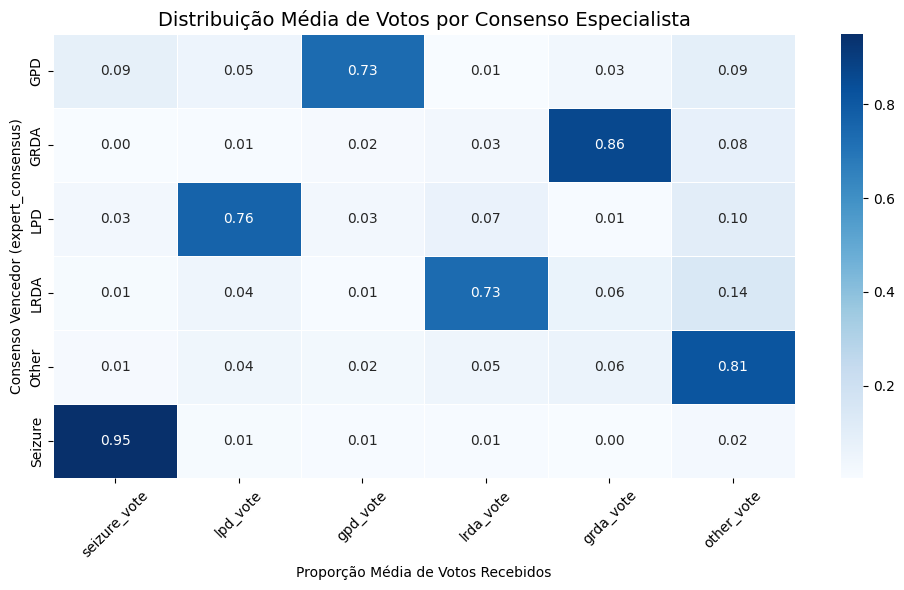

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(comparacao_votos, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Distribuição Média de Votos por Consenso Especialista', fontsize=14)
plt.ylabel('Consenso Vencedor (expert_consensus)')
plt.xlabel('Proporção Média de Votos Recebidos')
plt.xticks(rotation=45)
plt.tight_layout()

print("Tabela de Comparação de Votos:")
print(comparacao_votos)

In [10]:
matriz_correlacao = probs_df[vote_cols].corr()

Matriz de Correlação:
              seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
seizure_vote      1.000000 -0.221757 -0.161980  -0.254536  -0.286861   
lpd_vote         -0.221757  1.000000 -0.117910  -0.120059  -0.232497   
gpd_vote         -0.161980 -0.117910  1.000000  -0.215871  -0.197931   
lrda_vote        -0.254536 -0.120059 -0.215871   1.000000  -0.164458   
grda_vote        -0.286861 -0.232497 -0.197931  -0.164458   1.000000   
other_vote       -0.330510 -0.156898 -0.174864  -0.112608  -0.198498   

              other_vote  
seizure_vote   -0.330510  
lpd_vote       -0.156898  
gpd_vote       -0.174864  
lrda_vote      -0.112608  
grda_vote      -0.198498  
other_vote      1.000000  


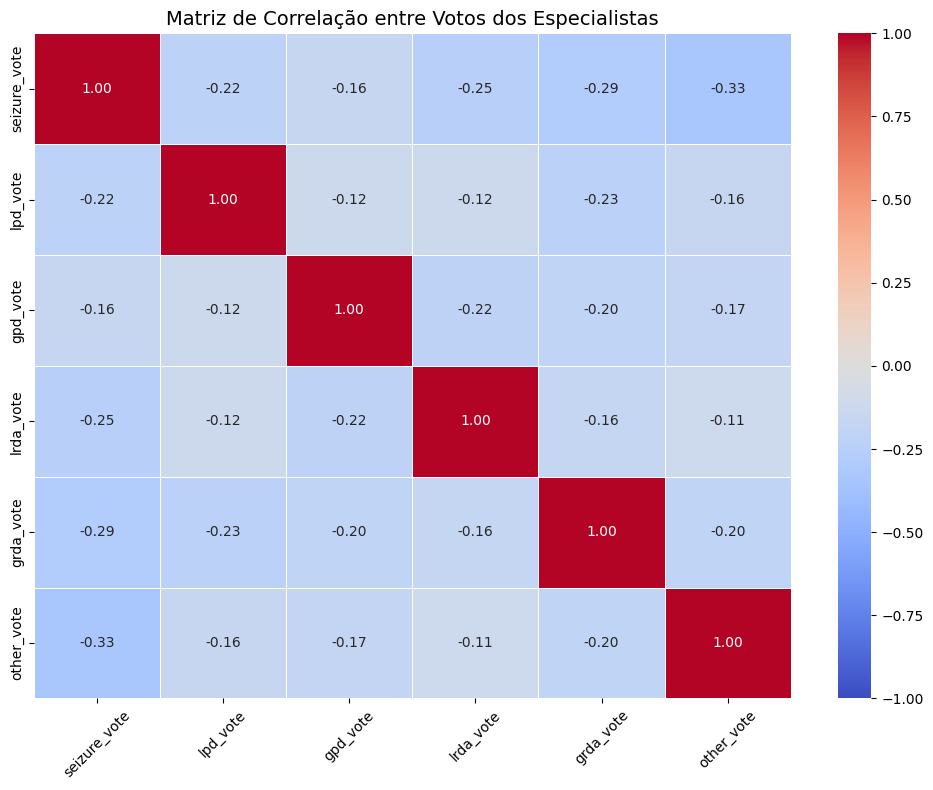

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlação entre Votos dos Especialistas', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

print("Matriz de Correlação:")
print(matriz_correlacao)

In [12]:
matriz_correlacao_bruta = df_train[vote_cols].corr()

Tabela de Correlação de Votos Brutos:
              seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
seizure_vote      1.000000 -0.126061  0.126841  -0.174617  -0.241683   
lpd_vote         -0.126061  1.000000 -0.059229   0.020348  -0.140632   
gpd_vote          0.126841 -0.059229  1.000000  -0.150559  -0.091000   
lrda_vote        -0.174617  0.020348 -0.150559   1.000000  -0.053259   
grda_vote        -0.241683 -0.140632 -0.091000  -0.053259   1.000000   
other_vote       -0.208527 -0.025377 -0.060530   0.074365   0.074807   

              other_vote  
seizure_vote   -0.208527  
lpd_vote       -0.025377  
gpd_vote       -0.060530  
lrda_vote       0.074365  
grda_vote       0.074807  
other_vote      1.000000  


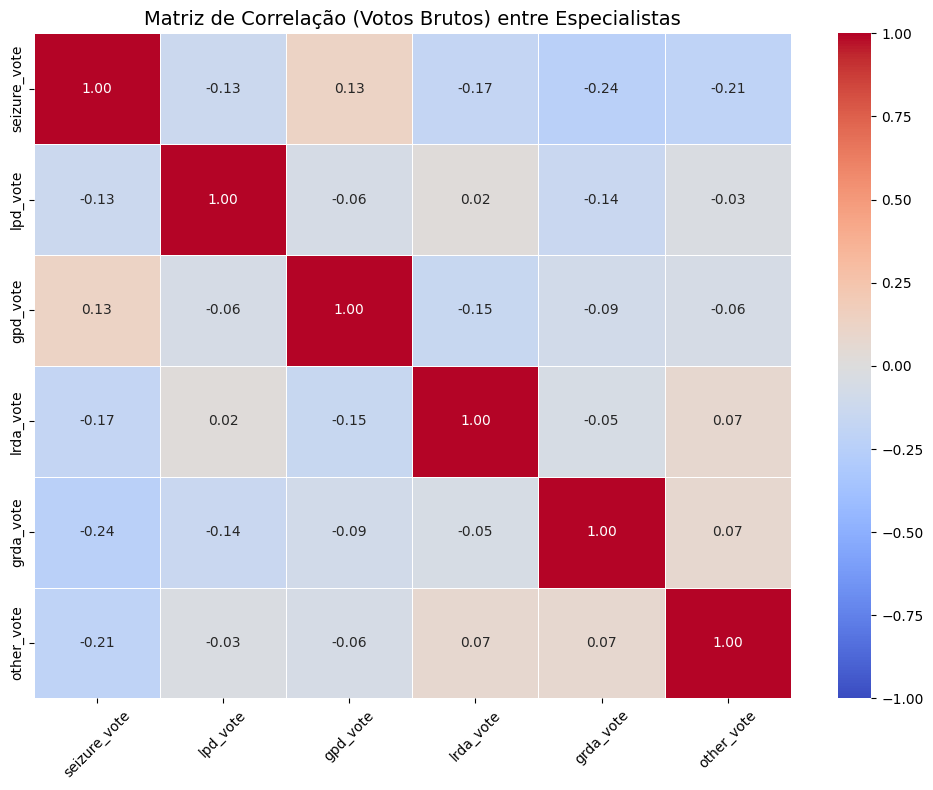

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(matriz_correlacao_bruta, annot=True, cmap='coolwarm', center=0, 
            fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlação (Votos Brutos) entre Especialistas', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

print("Tabela de Correlação de Votos Brutos:")
print(matriz_correlacao_bruta)